# Bibliothèques

In [ ]:
import numpy as np
import pandas as pd 
from tqdm import tqdm
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

from math import sqrt
from scipy import stats
from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

# Données de facturation

> Analyse des comportements des consommateurs

> Analyse des saisonnalités d'achat

In [ ]:
data_cmd = pd.read_csv('database_facturation_all.csv', sep=';', encoding='utf-8-sig')

In [10]:
data_cmd

,ID_COMPTE,DT_COMMANDE,NUM_ORDRE,STATUT,MONTANT_HT,REG_DAF1,LIB_DAF1,REG_DAF2,LIB_DAF2,REG_DAF3,LIB_DAF3,REG_DAF4,LIB_DAF4,GAMME_PRODUIT
0,10,2024-01-31,2575182400,Actif,0.00,D,Digital,DSV,Diversification BU,DSVCOM,Community Management,DDIOFERSOC,Classified,CM
1,100002,2024-10-10,2596574900,Actif,41.72,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBRUBR,Produits rubriqués,PUB CO
2,100002,2024-10-11,2596569700,Actif,0.00,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBHIST,Historique,PUB CO
3,100002,2024-10-11,2596575500,Actif,0.00,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO
4,100007,2022-05-10,2517678300,Actif,122.37,D,Digital,DDI,Display BU,DDIEDT,Editeurs PDLO,DDIEDTDCLS,Display classic Sites,DISPLAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910971,99996,2024-03-06,2579194200,Actif,0.00,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO
910972,99996,2024-03-06,2579194500,Actif,58.73,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO
910973,99996,2024-03-06,2579194600,Actif,28.66,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO
910974,99996,2024-03-06,2579194700,Actif,10.34,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO


# Analyse des saisonnalités

In [14]:
# Titre : "Volume de commandes par mois"
# Description : Nombre et Part de commandes par mois par année

# Conversion en datetime si nécessaire
data_cmd['DT_COMMANDE'] = pd.to_datetime(data_cmd['DT_COMMANDE'], errors='coerce')

data_cmd['MOIS'] = data_cmd['DT_COMMANDE'].dt.month  
data_cmd['ANNEE'] = data_cmd['DT_COMMANDE'].dt.year
annual_total = data_cmd.groupby(data_cmd['DT_COMMANDE'].dt.year)['NUM_ORDRE'].transform('count')  
data_cmd['NB_COMMANDES'] = data_cmd.groupby(['ANNEE', 'MOIS'])['NUM_ORDRE'].transform('count') # Nombre de commandes par mois
data_cmd['COMMANDES_NORM'] = (data_cmd.groupby(['ANNEE', 'MOIS'])['NUM_ORDRE'].transform('count')) / annual_total * 100 # Prct de commandes par mois à l'année


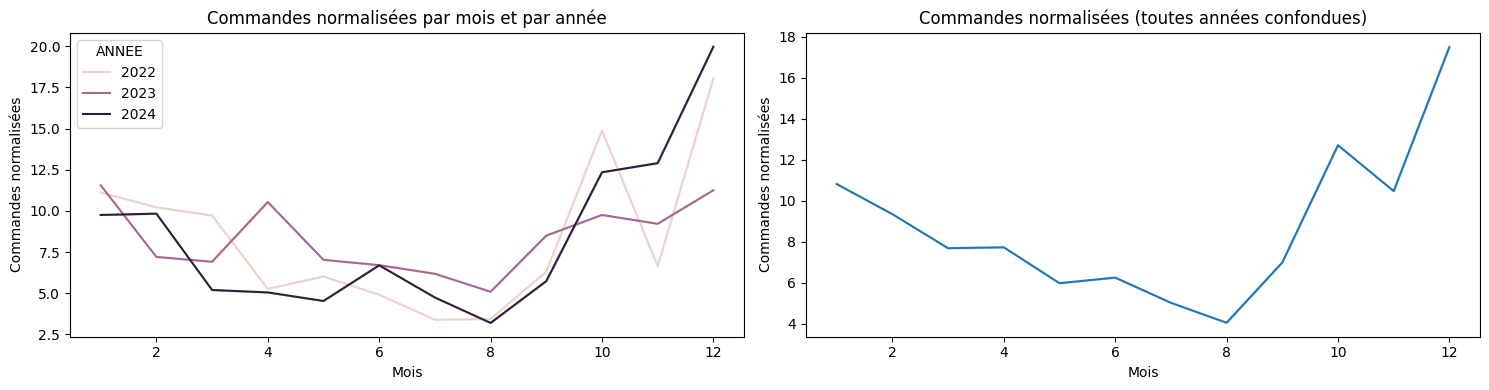

In [15]:
# Titre : "Evolution du volume d'achats par mois entre années"
# Description : Superposition des courbes mensuelles pour chaque année 
#               + Moyenne des commandes par mois sur toutes les années

plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=data_cmd, x='MOIS', y='COMMANDES_NORM', hue='ANNEE')
plt.title("Commandes normalisées par mois et par année")
plt.xlabel("Mois")
plt.ylabel("Commandes normalisées")

plt.subplot(1, 2, 2)
sns.lineplot(data=data_cmd, x='MOIS', y='COMMANDES_NORM')
plt.title("Commandes normalisées (toutes années confondues)")
plt.xlabel("Mois")
plt.ylabel("Commandes normalisées")

# Ajuster l'affichage
plt.tight_layout()
plt.show()

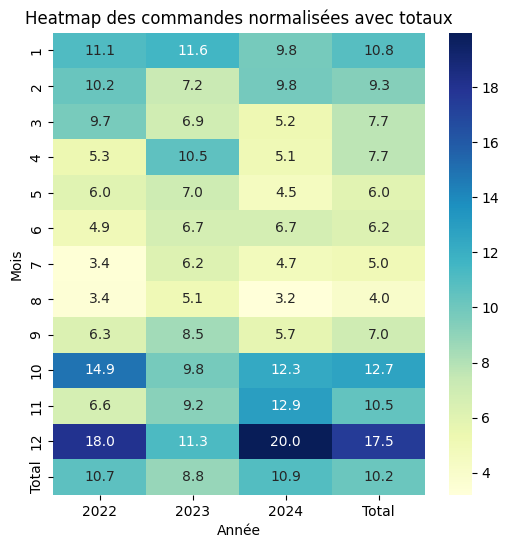

In [ ]:
# Titre : "Intensité des achats par période (mois × année)"
# Description : Carte thermique montrant les périodes fortes/faibles

# Créer le pivot avec les marges
pivot_norm = data_cmd.pivot_table(
    index='MOIS',
    columns='ANNEE',
    values='COMMANDES_NORM',
    aggfunc='mean',
    margins=True,
    margins_name='Total'
)

# Tracer la heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(pivot_norm, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Heatmap des commandes normalisées avec totaux")
plt.xlabel("Année")
plt.ylabel("Mois")
plt.show()



Calcul des clusters KMeans: 100%|██████████| 4/4 [00:00<00:00, 10.36it/s]


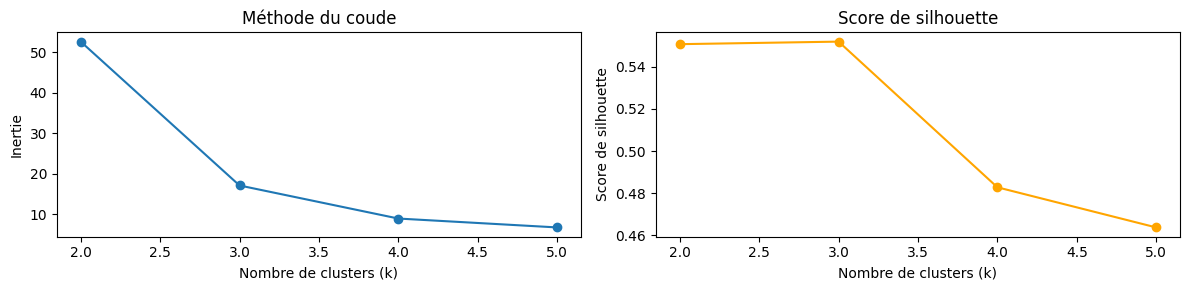

,MOIS,MOYENNE_COMMANDE,CLUSTER,SAISON
0,1,10.807342,1,HAUTE
1,2,9.338113,1,HAUTE
2,3,7.676062,3,MOYENNE
3,4,7.720721,3,MOYENNE
4,5,5.968533,3,MOYENNE
5,6,6.242696,3,MOYENNE
6,7,5.012567,0,BASSE
7,8,4.038721,0,BASSE
8,9,6.979598,3,MOYENNE
9,10,12.701166,1,HAUTE


In [17]:
# Moyenne des commandes normalisées par mois
commande_mois = data_cmd.groupby('MOIS')['COMMANDES_NORM'].mean().reset_index()
commande_mois.columns = ['MOIS', 'MOYENNE_COMMANDE']


inertias = []
silhouette_scores = []
k_range = range(2, 6)

for k in tqdm(k_range, desc="Calcul des clusters KMeans"):
    # Entrainement du modèle KMeans
    kmeans = KMeans(n_clusters=k, random_state=241)
    kmeans.fit(commande_mois[['MOYENNE_COMMANDE']])

    # Calcul de l'inertie
    inertias.append(kmeans.inertia_)
    
    # Calcul du score de silhouette
    score = silhouette_score(commande_mois[['MOYENNE_COMMANDE']], kmeans.labels_)
    silhouette_scores.append(score)


# Tracer la méthode du coude
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title("Méthode du coude")

# Tracer le score de silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de silhouette')
plt.title("Score de silhouette")
plt.tight_layout()
plt.show()


# KMeans sur les moyennes mensuelles
kmeans = KMeans(n_clusters=4, random_state=241)
commande_mois['CLUSTER'] = kmeans.fit_predict(commande_mois[['MOYENNE_COMMANDE']])

# On trie les clusters par intensité de commande
cluster_order = commande_mois.groupby('CLUSTER')['MOYENNE_COMMANDE'].mean().sort_values().index

# Attribution des labels saisonniers
season_labels = ['BASSE', 'MOYENNE', 'HAUTE', 'TRES HAUTE']
cluster_map = dict(zip(cluster_order, season_labels))
commande_mois['SAISON'] = commande_mois['CLUSTER'].map(cluster_map)

# Resultats
commande_mois

# Analyse ciblée comportement d'achats

> Il faudrait observer les délais d'achat moyens par classe PMG pour affiner les new_indicators de co_appetence

In [19]:
data_cmd

,ID_COMPTE,DT_COMMANDE,NUM_ORDRE,STATUT,MONTANT_HT,REG_DAF1,LIB_DAF1,REG_DAF2,LIB_DAF2,REG_DAF3,LIB_DAF3,REG_DAF4,LIB_DAF4,GAMME_PRODUIT,MOIS,ANNEE,NB_COMMANDES,COMMANDES_NORM
0,10,2024-01-31,2575182400,Actif,0.00,D,Digital,DSV,Diversification BU,DSVCOM,Community Management,DDIOFERSOC,Classified,CM,1,2024,32965,9.755643
1,100002,2024-10-10,2596574900,Actif,41.72,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBRUBR,Produits rubriqués,PUB CO,10,2024,41727,12.348664
2,100002,2024-10-11,2596569700,Actif,0.00,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBHIST,Historique,PUB CO,10,2024,41727,12.348664
3,100002,2024-10-11,2596575500,Actif,0.00,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO,10,2024,41727,12.348664
4,100007,2022-05-10,2517678300,Actif,122.37,D,Digital,DDI,Display BU,DDIEDT,Editeurs PDLO,DDIEDTDCLS,Display classic Sites,DISPLAY,5,2022,17651,6.026515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910971,99996,2024-03-06,2579194200,Actif,0.00,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO,3,2024,17579,5.202319
910972,99996,2024-03-06,2579194500,Actif,58.73,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO,3,2024,17579,5.202319
910973,99996,2024-03-06,2579194600,Actif,28.66,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO,3,2024,17579,5.202319
910974,99996,2024-03-06,2579194700,Actif,10.34,P,Print,PPC,Pub Co PDLO,PPCPUB,Pub Co,PPCPUBMOLC,Module - locales,PUB CO,3,2024,17579,5.202319


In [20]:
# Étape 1 : ajouter la colonne YEAR_SUMMARY
data_cmd['YEAR_SUMMARY'] = data_cmd['DT_COMMANDE'].dt.year

# Étape 2 : grouper par ID_COMPTE et YEAR_SUMMARY
grouped = data_cmd.groupby(['ID_COMPTE', 'YEAR_SUMMARY'])

# Étape 3 : calculer les métriques demandées
df_summary = grouped.agg(
    NB_COMMANDE=('DT_COMMANDE', 'nunique'),
    NB_GP=('GAMME_PRODUIT', 'nunique'),
    CA_ANNUEL_ADDITI=('MONTANT_HT', 'sum')
).reset_index()

# Étape 4 : calcul des délais moyens et variances
def calculate_delai_stats(dates):
    if len(dates) > 1:
        deltas = (dates - dates.shift()).dropna().dt.days
        return deltas.mean(), deltas.var()
    return None, None

# Appliquer par ID_COMPTE et YEAR_SUMMARY
delai_stats = data_cmd.sort_values('DT_COMMANDE').groupby(['ID_COMPTE', 'YEAR_SUMMARY'])['DT_COMMANDE'] \
    .apply(lambda x: pd.Series(calculate_delai_stats(x))).unstack()
delai_stats.columns = ['MOY_DELAI', 'VAR_DELAI']
delai_stats = delai_stats.reset_index()

# Fusionner avec df_summary
df_summary = df_summary.merge(delai_stats, on=['ID_COMPTE', 'YEAR_SUMMARY'], how='left')

# Sécurité finale : regrouper à nouveau pour éviter les doublons potentiels
df_summary = df_summary.groupby(['ID_COMPTE', 'YEAR_SUMMARY'], as_index=False).agg({
    'NB_COMMANDE': 'max',  
    'NB_GP': 'max',
    'CA_ANNUEL_ADDITI': 'max',
    'MOY_DELAI': 'max',
    'VAR_DELAI': 'max'})

# Étape 5 : classification PMG
def classify_pmg(ca):
    if ca >= 50000:
        return 'Très gros'
    elif ca >= 20000:
        return 'Gros'
    elif ca >= 5000:
        return 'Moyen'
    elif ca >= 1500:
        return 'Petit'
    elif ca > 0:
        return 'Très petit'
    elif ca == 0:
        return 'Hors catégorie'
    else:
        return 'X'

df_summary['CLASSE_PMG'] = df_summary['CA_ANNUEL_ADDITI'].apply(classify_pmg)

# Étape 6 : filtrer les lignes à supprimer
df_summary = df_summary[~(
    ((df_summary['CLASSE_PMG'].isin(['X', 'Hors catégorie'])) | (df_summary['NB_COMMANDE'] <= 1))
)].reset_index(drop=True)


df_summary

,ID_COMPTE,YEAR_SUMMARY,NB_COMMANDE,NB_GP,CA_ANNUEL_ADDITI,MOY_DELAI,VAR_DELAI,CLASSE_PMG
0,10,2024,2,5,1974.95,0.416667,2.083333,Petit
1,18,2022,4,6,7361.54,5.638889,842.180159,Moyen
2,22,2022,2,1,401.77,3.781818,786.618182,Très petit
3,22,2023,3,4,4862.83,1.744565,519.480845,Petit
4,22,2024,3,1,1236.71,13.428571,2329.648352,Très petit
...,...,...,...,...,...,...,...,...
11500,947186,2024,2,1,11038.66,0.037975,0.113924,Moyen
11501,947227,2024,3,1,1474.16,0.428571,1.802198,Très petit
11502,947229,2024,2,1,16330.69,0.25,0.75,Moyen
11503,948246,2024,2,2,3350.00,12.0,NaN,Petit


In [21]:
df_summary['CLASSE_PMG'].value_counts(normalize=True)*100

CLASSE_PMG
Petit         34.219904
Très petit    28.448501
Moyen         28.431117
Gros           6.466754
Très gros      2.433724
Name: proportion, dtype: float64

In [22]:
# Calcul des statistiques par CLASSE_PMG
df_stats = df_summary.groupby('CLASSE_PMG').agg(
    MEAN_NB_COMM=('NB_COMMANDE', 'mean'),
    MEAN_NB_GP=('NB_GP', 'mean'),
    MEDIAN_MOY_DELAI=('MOY_DELAI', 'median'),
    MEAN_MOY_DELAI=('MOY_DELAI', 'mean'),
    VAR_MOY_DELAI=('MOY_DELAI', 'var'),
    STD_MOY_DELAI=('MOY_DELAI', 'std')
).reset_index()

# Affichage du tableau avec arrondi sans décimales
display(df_stats.round(0))

,CLASSE_PMG,MEAN_NB_COMM,MEAN_NB_GP,MEDIAN_MOY_DELAI,MEAN_MOY_DELAI,VAR_MOY_DELAI,STD_MOY_DELAI
0,Gros,9.0,4.0,2.423535,5.206465,147.539646,12.0
1,Moyen,6.0,3.0,4.016129,7.112334,146.082862,12.0
2,Petit,4.0,2.0,5.833333,10.945631,310.144126,18.0
3,Très gros,15.0,4.0,1.413194,3.088813,48.750179,7.0
4,Très petit,3.0,2.0,9.48,21.360555,1372.923355,37.0


In [ ]:
# Vérification des valeurs extrêmes dans la distribution des délais
    # on calcul de l'écart absolu entre la moyenne et la médiane et on vérifie s'il est supérieur à 15%
for index, row in df_stats.iterrows():
    ecart_abs = abs(row['MEAN_MOY_DELAI'] - row['MEDIAN_MOY_DELAI']) / row['MEDIAN_MOY_DELAI']
    if ecart_abs > 0.15:
        print(f"{row['CLASSE_PMG']} - Écart absolu: {ecart_abs:.2f} (> 15%) - Outliers")
    else:
        print(f"{row['CLASSE_PMG']} - Écart absolu: {ecart_abs:.2f} (<= 15%) - Pas d outliers")
        

Gros - Écart absolu: 1.15 (> 15%) - Outliers
Moyen - Écart absolu: 0.77 (> 15%) - Outliers
Petit - Écart absolu: 0.88 (> 15%) - Outliers
Très gros - Écart absolu: 1.19 (> 15%) - Outliers
Très petit - Écart absolu: 1.25 (> 15%) - Outliers


In [ ]:
# Définir les valeurs de alpha pour chaque CLASSE_PMG

# les valeurs de alpha sont des paramètres permettant arbitrairement de capturer les écarts au sein d'une catégorie
alpha_values = {
    'Très gros': 0.5,
    'Gros': 1,
    'Moyen': 1,
    'Petit': 2,
    'Très petit': 2
}

# Calculer la colonne SEUIL
    # Les seuils représentent les délais médians d'achat
df_stats['SEUIL'] = df_stats.apply(
    lambda row: row['MEDIAN_MOY_DELAI'] + alpha_values[row['CLASSE_PMG']] * row['STD_MOY_DELAI'], axis=1 # On n'utilise que la médiane car on a des outliers partout
)

df_stats[['CLASSE_PMG','SEUIL']].round(0)



,CLASSE_PMG,SEUIL
0,Gros,15.0
1,Moyen,16.0
2,Petit,41.0
3,Très gros,5.0
4,Très petit,84.0
